In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Pytorch: {torch.__version__}")
print(f"Device: {device}")

Pytorch: 2.10.0+cu128
Device: cuda


In [4]:
"""

Variational autoencoders (VAEs) are generative models used in machine learning (ML) to generate new data
in the form of variations of the input data they’re trained on. In addition to this, they also perform tasks common to other autoencoders,
such as denoising.

Loss = Reconstruction Loss + KL Divergence

1. RECONSTRUCTION LOSS
   • Same as regular AE: MSE or BCE
   • How well does decoder reconstruct input?

2. KL DIVERGENCE
   • Regularizes latent space
   • Forces q(z|x) to be close to N(0,1)
   • KL(q(z|x) || p(z)) where p(z) = N(0,1)

   KL = -0.5 × Σ(1 + log(σ²) - μ² - σ²)

  Why KL divergence?
  • Without it: encoder could output huge variances
  • Forces latent space to be organized
  • Enables smooth interpolation between samples

  β = weight for KL term (often 1, or annealed)

  """


'\n\nVariational autoencoders (VAEs) are generative models used in machine learning (ML) to generate new data \nin the form of variations of the input data they’re trained on. In addition to this, they also perform tasks common to other autoencoders, \nsuch as denoising.\n\nLoss = Reconstruction Loss + KL Divergence\n\n1. RECONSTRUCTION LOSS\n   • Same as regular AE: MSE or BCE\n   • How well does decoder reconstruct input?\n\n2. KL DIVERGENCE\n   • Regularizes latent space\n   • Forces q(z|x) to be close to N(0,1)\n   • KL(q(z|x) || p(z)) where p(z) = N(0,1)\n\n   KL = -0.5 × Σ(1 + log(σ²) - μ² - σ²)\n\n  Why KL divergence?\n  • Without it: encoder could output huge variances\n  • Forces latent space to be organized\n  • Enables smooth interpolation between samples\n\n  β = weight for KL term (often 1, or annealed)\n\n  '

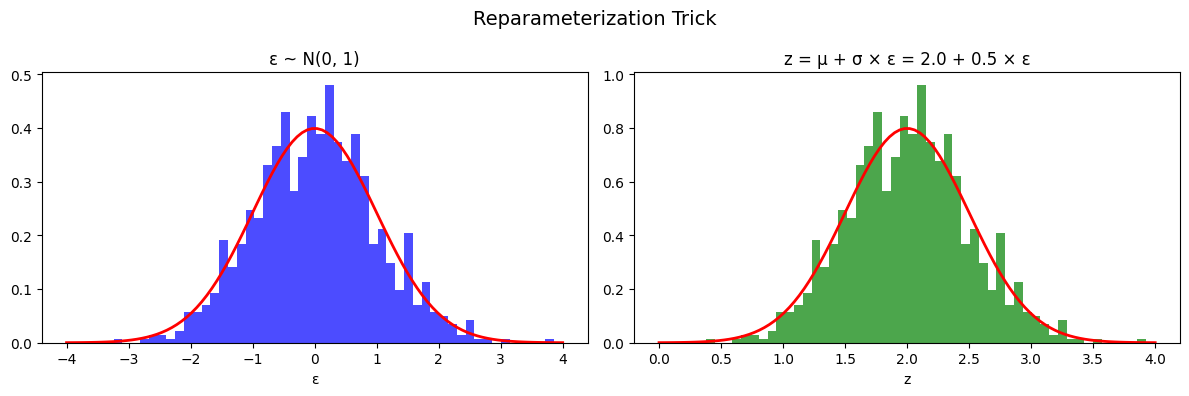

In [5]:
# Visualize reparameterization
mu = 2.0
sigma = 0.5

# Sample epsilon from N(0,1)
epsilon = np.random.randn(1000)

# Transform to N(mu, sigma^2)
z = mu + sigma * epsilon

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(epsilon, bins=50, density=True, alpha=0.7, color='blue')
x = np.linspace(-4, 4, 100)
axes[0].plot(x, norm.pdf(x, 0, 1), 'r-', linewidth=2)
axes[0].set_title('ε ~ N(0, 1)')
axes[0].set_xlabel('ε')

axes[1].hist(z, bins=50, density=True, alpha=0.7, color='green')
x = np.linspace(0, 4, 100)
axes[1].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2)
axes[1].set_title(f'z = μ + σ × ε = {mu} + {sigma} × ε')
axes[1].set_xlabel('z')

plt.suptitle('Reparameterization Trick', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
transform = transforms.Compose([
    transforms.ToTensor()
])

#load MNIST
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set size: {len(train_loader.dataset)}")
print(f"Test set size: {len(test_loader.dataset)}")
print(f"Batch size: {BATCH_SIZE}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.93MB/s]

Train set size: 60000
Test set size: 10000
Batch size: 128


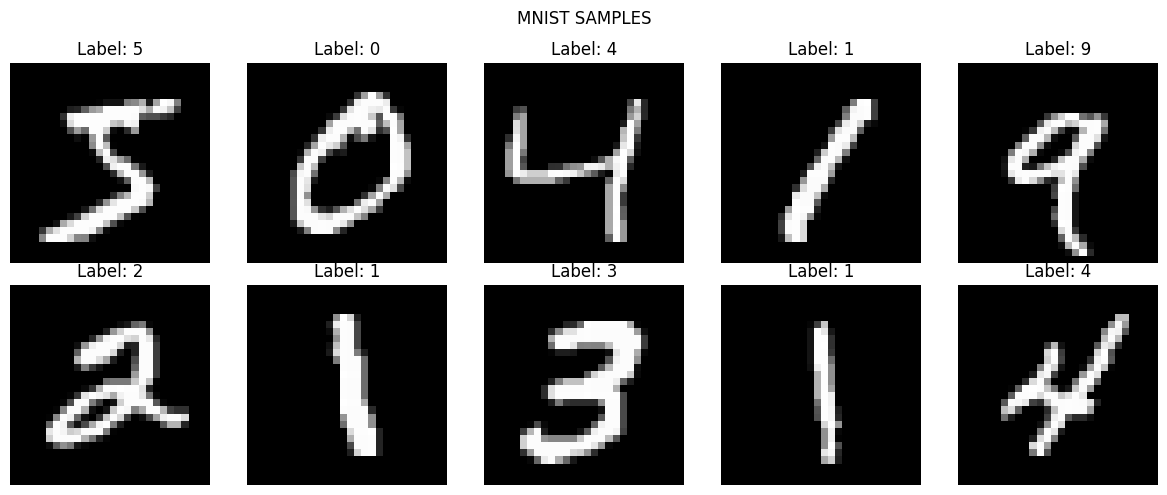

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
  img, label = train_dataset[i]
  ax.imshow(img.squeeze(), cmap='gray')
  ax.set_title(f'Label: {label}')
  ax.axis('off')
plt.suptitle('MNIST SAMPLES')
plt.tight_layout()
plt.show()

Building a VAE Model

In [22]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Latent space parameters
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        """Encode input to latent distribution parameters"""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)  # log(σ²) for numerical stability
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = μ + σ × ε"""
        std = torch.exp(0.5 * logvar)  # σ = exp(0.5 × log(σ²))
        eps = torch.randn_like(std)     # ε ~ N(0, 1)
        z = mu + std * eps              # z = μ + σ × ε
        return z

    def decode(self, z):
        """Decode latent vector to reconstruction"""
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

print("VAE class defined")

VAE class defined


In [23]:
LATENT_DIM = 2  #used for 3d visualization

model = VAE(input_dim=784, hidden_dim=400, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Latent dimensions: {LATENT_DIM}")
print(f"Total Parameters: {total_params:,}")
print(f"\n Model Architecture")
print(model)

Latent dimensions: 2
Total Parameters: 951,988

 Model Architecture
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


VAE Loss function

In [24]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
  recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + beta * kl_loss, recon_loss, kl_loss

Training

In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, beta=1.0):
  model.train()
  total_loss, total_recon, total_kl = 0, 0, 0
  for data, _ in loader:
    data = data.view(-1, 784).to(device)
    optimizer.zero_grad()
    x_recon, mu, logvar = model(data)
    loss, recon, kl = vae_loss(x_recon, data, mu, logvar, beta)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    total_recon += recon.item()
    total_kl += kl.item()
  n = len(loader.dataset)
  return total_loss / n, total_recon / n, total_kl / n

def evaluate(model, loader, beta=1.0):
  model.eval()
  total_loss, total_recon, total_kl = 0, 0, 0
  with torch.no_grad():
    for data, _ in loader:
      data = data.view(-1, 784).to(device)
      x_recon, mu, logvar = model(data)
      loss, recon, kl = vae_loss(x_recon, data, mu, logvar, beta)
      total_loss += loss.item()
      total_recon += recon.item()
      total_kl += kl.item()
  n = len(loader.dataset)
  return total_loss / n, total_recon / n, total_kl / n

In [26]:
from prompt_toolkit import history
EPOCHS = 30
BETA = 1.0

history = {
    'train_loss': [],
    'train_recon': [],
    'train_kl': [],
    'val_loss': [],
    'val_recon': [],
    'val_kl': []
}

print('Training . . .')

for epoch in range(EPOCHS):
  train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, BETA)
  val_loss, val_recon, val_kl = evaluate(model, test_loader, BETA)

  history['train_loss'].append(train_loss)
  history['train_recon'].append(train_recon)
  history['train_kl'].append(train_kl)
  history['val_loss'].append(val_loss)
  history['val_recon'].append(val_recon)
  history['val_kl'].append(val_kl)

  if (epoch + 1) % 5 == 0:
    print(f"Epoch: {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Recon: {train_recon:.4f}, Train KL: {train_kl:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Recon: {val_recon:.4f}, Val KL: {val_kl:.4f}")
    print('-' * 30)

Training . . .
Epoch: 5/30
Train Loss: 147.8723, Train Recon: 141.7481, Train KL: 6.1242
Val Loss: 147.7448, Val Recon: 141.5687, Val KL: 6.1761
------------------------------
Epoch: 10/30
Train Loss: 142.9631, Train Recon: 136.5109, Train KL: 6.4522
Val Loss: 144.2155, Val Recon: 137.5249, Val KL: 6.6906
------------------------------
Epoch: 15/30
Train Loss: 140.7335, Train Recon: 134.1273, Train KL: 6.6062
Val Loss: 142.2524, Val Recon: 135.7291, Val KL: 6.5233
------------------------------
Epoch: 20/30
Train Loss: 139.4273, Train Recon: 132.7195, Train KL: 6.7078
Val Loss: 141.1142, Val Recon: 134.4523, Val KL: 6.6619
------------------------------
Epoch: 25/30
Train Loss: 138.2820, Train Recon: 131.4713, Train KL: 6.8107
Val Loss: 140.1448, Val Recon: 133.3729, Val KL: 6.7719
------------------------------
Epoch: 30/30
Train Loss: 137.6159, Train Recon: 130.7198, Train KL: 6.8961
Val Loss: 139.5492, Val Recon: 132.6000, Val KL: 6.9492
------------------------------


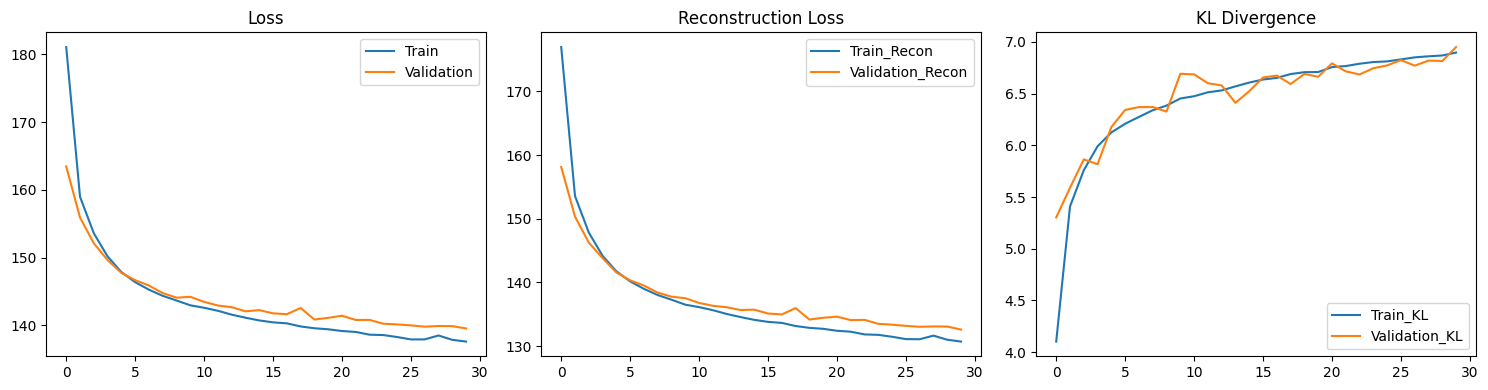

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_recon'], label='Train_Recon')
axes[1].plot(history['val_recon'], label='Validation_Recon')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

axes[2].plot(history['train_kl'], label='Train_KL')
axes[2].plot(history['val_kl'], label='Validation_KL')
axes[2].set_title('KL Divergence')
axes[2].legend()

plt.tight_layout()
plt.show()

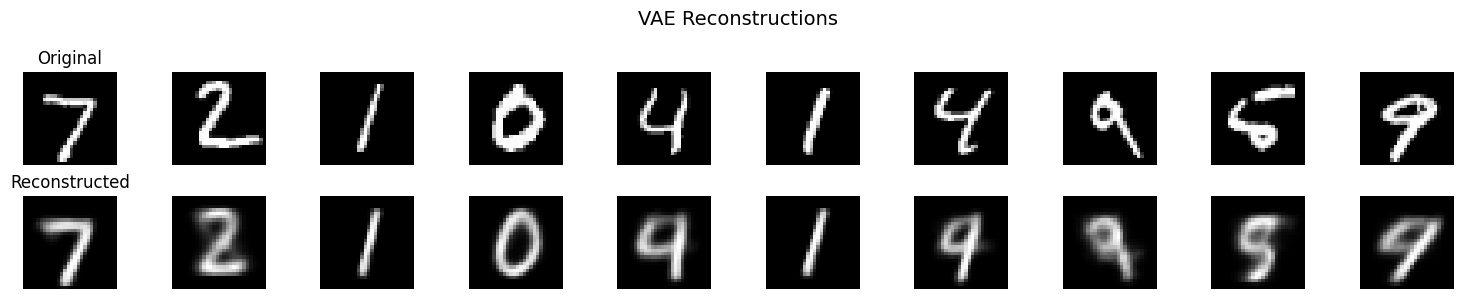

In [33]:
# Get reconstructions
model.eval()

test_batch, test_labels = next(iter(test_loader))
test_batch = test_batch.view(-1, 784).to(device)

with torch.no_grad():
    recon_batch, _, _ = model(test_batch)

# Plot
n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 3))

for i in range(n):
    axes[0, i].imshow(test_batch[i].cpu().view(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    axes[1, i].imshow(recon_batch[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Reconstructed')

plt.suptitle('VAE Reconstructions', fontsize=14)
plt.tight_layout()
plt.show()

Visualizing the latent space

In [36]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
  for data, labels in test_loader:
    data = data.view(-1, 784).to(device)
    mu, _ = model.encode(data)
    all_mu.append(mu.cpu().numpy())
    all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Shape of all_mu: {all_mu.shape}")
print(f"Shape of all_labels: {all_labels.shape}")

Shape of all_mu: (10000, 2)
Shape of all_labels: (10000,)


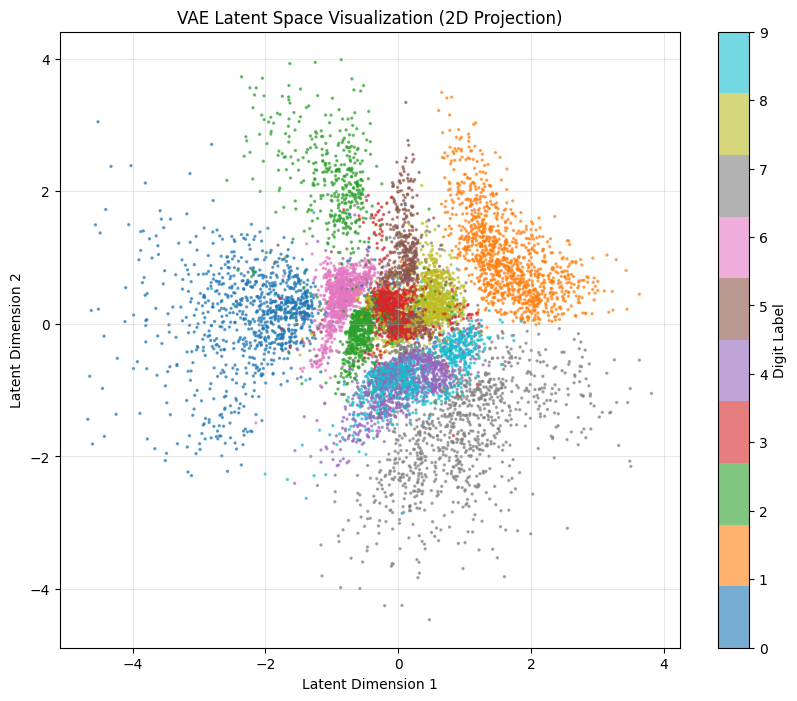

In [48]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.6, s=2)
plt.colorbar(scatter, label='Digit Label')
plt.title('VAE Latent Space Visualization (2D Projection)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

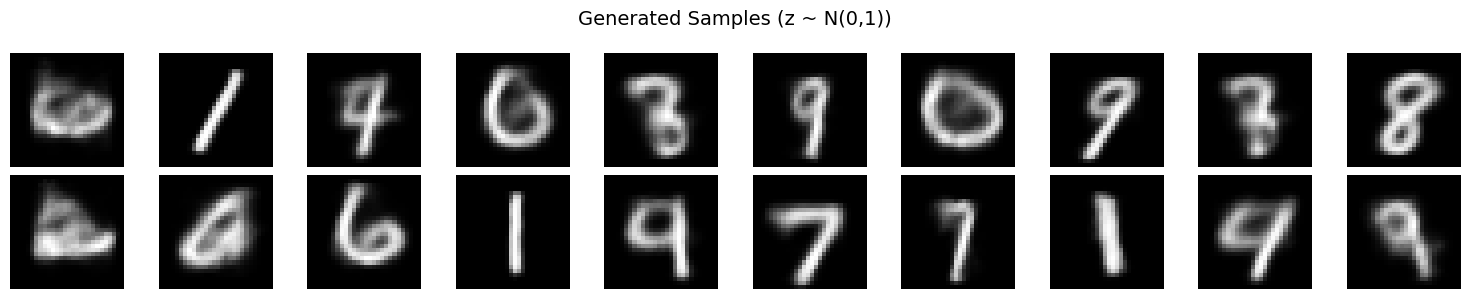

In [39]:
# Generate samples from random latent vectors
model.eval()

n_samples = 20

# Sample from N(0, 1)
z_random = torch.randn(n_samples, LATENT_DIM).to(device)

with torch.no_grad():
    generated = model.decode(z_random)

# Plot
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].cpu().view(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle('Generated Samples (z ~ N(0,1))', fontsize=14)
plt.tight_layout()
plt.show()

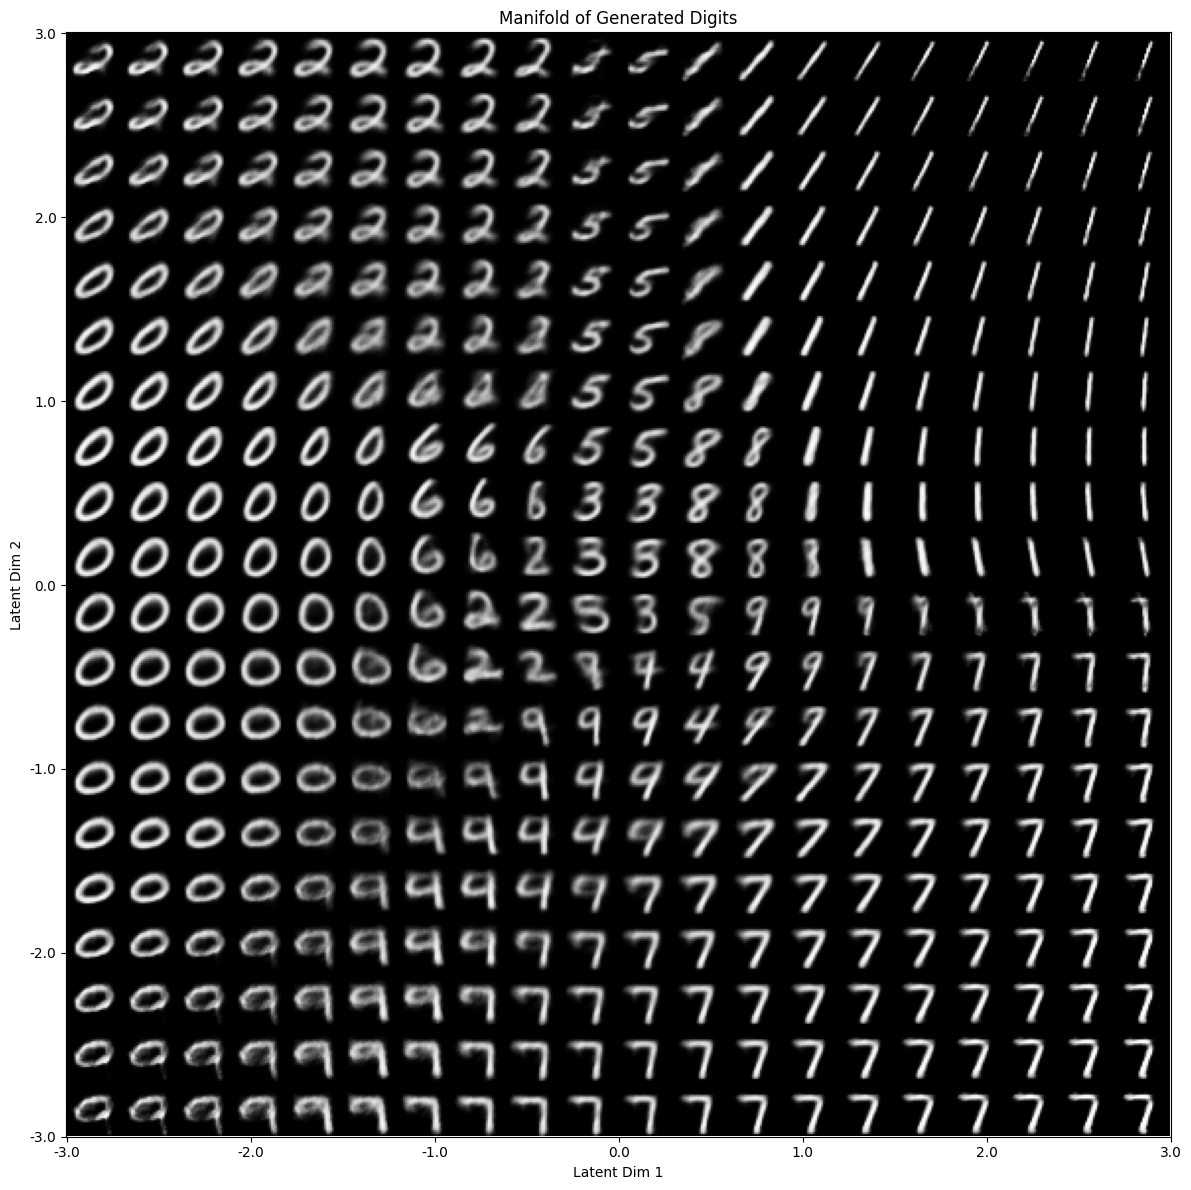

Notice smooth transitions between digits!


In [40]:
# Generate grid by sampling latent space
n = 20
digit_size = 28

# Create grid of latent points
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)[::-1]

figure = np.zeros((digit_size * n, digit_size * n))

model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded.cpu().view(digit_size, digit_size).numpy()
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(12, 12))
plt.imshow(figure, cmap='gray')
plt.xlabel('Latent Dim 1')
plt.ylabel('Latent Dim 2')
plt.title('Manifold of Generated Digits')
plt.xticks(np.linspace(0, digit_size * n, 7), [f'{x:.1f}' for x in np.linspace(-3, 3, 7)])
plt.yticks(np.linspace(0, digit_size * n, 7), [f'{x:.1f}' for x in np.linspace(3, -3, 7)])
plt.tight_layout()
plt.show()

print("Notice smooth transitions between digits!")

/tmp/ipykernel_445/698821276.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x1 = torch.tensor(test_dataset[idx1][0].view(1, 784)).to(device)
/tmp/ipykernel_445/698821276.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x2 = torch.tensor(test_dataset[idx2][0].view(1, 784)).to(device)


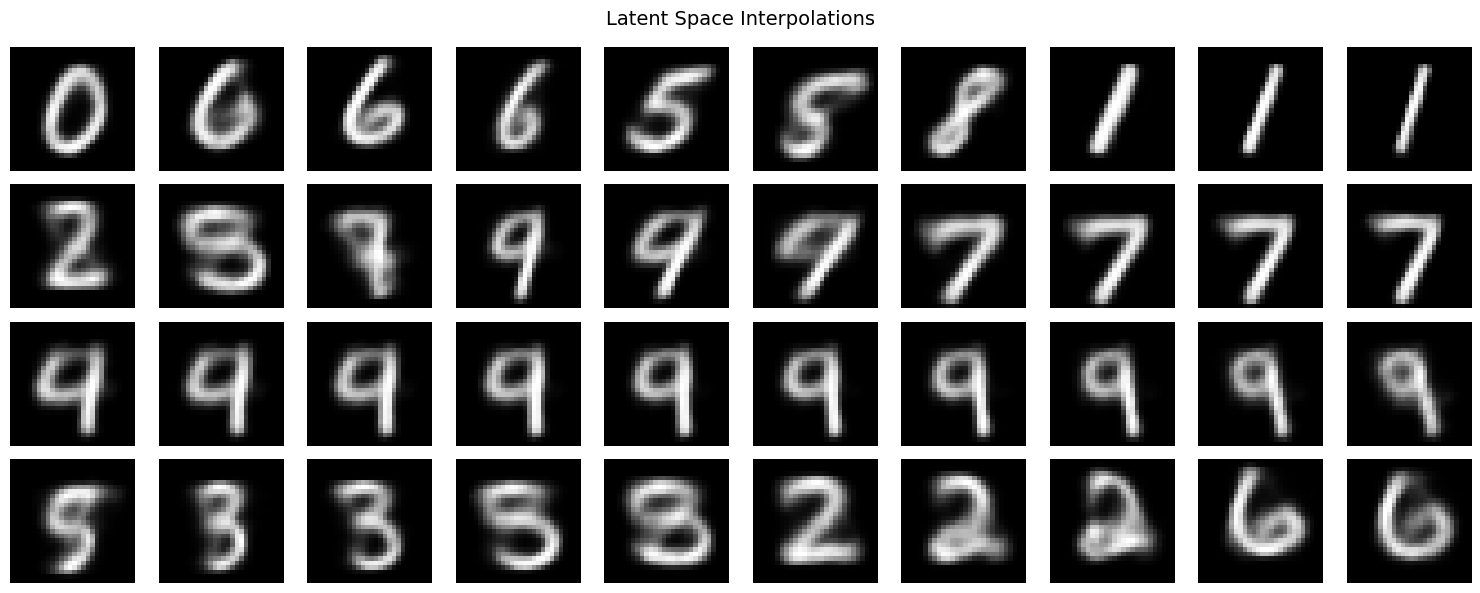

In [43]:
#interpolations
digit_pairs = [(0, 1), (2, 7), (4, 9), (5, 6)]

fig, axes = plt.subplots(len(digit_pairs), 10, figsize=(15, 6))

for row, (d1, d2) in enumerate(digit_pairs):
    idx1 = np.where(all_labels == d1)[0][0]
    idx2 = np.where(all_labels == d2)[0][0]

    x1 = torch.tensor(test_dataset[idx1][0].view(1, 784)).to(device)
    x2 = torch.tensor(test_dataset[idx2][0].view(1, 784)).to(device)

    interpolations = interpolate(model, x1, x2, n_steps=10)

    for col, img in enumerate(interpolations):
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(f'{d1}→{d2}', fontsize=12, rotation=0, labelpad=20)

plt.suptitle('Latent Space Interpolations', fontsize=14)
plt.tight_layout()
plt.show()

Convolutional VAE

In [49]:
class ConvVAE(nn.Module):
  def __init__(self, latent_dim=16):
    super(ConvVAE, self).__init__()

    self.latent_dim = latent_dim

    # Encoder
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
    )

    self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
    self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    # Decoder
    self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
        nn.Sigmoid()
    )

  def encode(self, x):
    h = self.encoder(x)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

  def decode(self, z):
    h = self.fc_decode(z)
    h = h.view(-1, 64, 7, 7)
    return self.decoder(h)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar

# Instantiate outside the class definition
conv_vae = ConvVAE(latent_dim=16).to(device)
total_params = sum(p.numel() for p in conv_vae.parameters())
print(f"Total Parameters: {total_params:,}")
print(f"\nModel Architecture")
print(conv_vae)

Total Parameters: 191,265

Model Architecture
ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=16, bias=True)
  (fc_decode): Linear(in_features=16, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


In [50]:
# Train Conv VAE
optimizer_conv = optim.Adam(conv_vae.parameters(), lr=1e-3)

def train_conv_vae(model, loader, optimizer, beta=1.0):
    model.train()
    total_loss = 0

    for data, _ in loader:
        data = data.to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(data)
        recon_loss = F.binary_cross_entropy(recon, data, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kl_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader.dataset)

print("Training Convolutional VAE...")
for epoch in range(20):
    loss = train_conv_vae(conv_vae, train_loader, optimizer_conv)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/20 | Loss: {loss:.2f}")

Training Convolutional VAE...
Epoch  5/20 | Loss: 110.17
Epoch 10/20 | Loss: 105.73
Epoch 15/20 | Loss: 103.93
Epoch 20/20 | Loss: 102.85


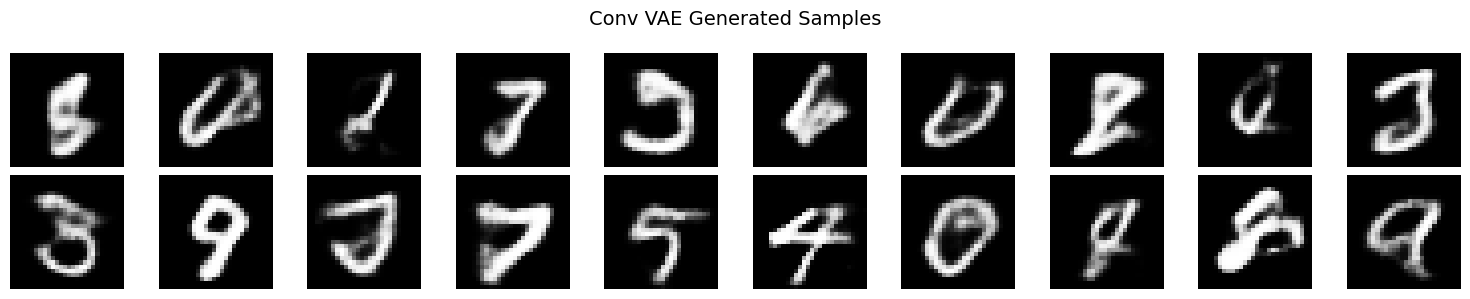

In [51]:
# Generate from Conv VAE
conv_vae.eval()
z_random = torch.randn(20, 16).to(device)

with torch.no_grad():
    generated_conv = conv_vae.decode(z_random)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_conv[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('Conv VAE Generated Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
import os
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-57-vae'
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), f'{save_path}/vae_mnist.pt')
torch.save(conv_vae.state_dict(), f'{save_path}/conv_vae_mnist.pt')

print(f"Saved to: {save_path}")

Mounted at /content/drive
Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-57-vae
